In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import Bio
from Bio import SeqIO
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord
import os
import sys
import glob

In [3]:
#ML modules
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [50]:
#concatenate the lineage assignations for all Colombian samples
datasets = []
for file in glob.glob('/Users/ricardorivero/Documents/DENV/dimensionality_reduction/*.tsv'):
    datasets.append(pd.read_table(file))

#string to drop from  observations
df = pd.concat(datasets, ignore_index=True)
substring = "When calculating seed matches: Unable to align"
filtered_datasets = df[~df['errors'].str.startswith(substring, na=False)]
filtered_datasets = filtered_datasets[['seqName','clade','aaSubstitutions', 'aaDeletions', 'aaInsertions']]
filtered_datasets['strain'] = filtered_datasets['seqName'].str.split('|').str[0] 


In [51]:
gisaid_metadata = pd.read_table('/Users/ricardorivero/Documents/DENV/dimensionality_reduction/colombian_seqs_pca.tsv')

#merge the datasets to assign lineages
gisaid_metadata = gisaid_metadata.merge(filtered_datasets, left_on='Virus name', right_on='strain', how='left')

In [55]:
gisaid_metadata['clade'].unique()

array(['2III_D.2', '1V_D', '1V_D.1', '1V_D.1.2', '1V_F', '1V_D.2',
       '2III_D.3', '3III_C.2', '3III_C.1', '4II_B.1', '1V', '4II_B',
       '1V_G', '2III_B', '2II_F.1.1.2', '1V_E.1', '1V_D.1.1', '4II_B.1.2',
       '1V_A', '3III_A'], dtype=object)

/Users/ricardorivero/anaconda3/lib/python3.11/site-packages/Bio/Seq.py:2879: BiopythonWarning: Partial codon, len(sequence) not a multiple of three. Explicitly trim the sequence or add trailing N before translation. This may become an error in future.
  warnings.warn(


0    hDenV1/Colombia/RIS-INS-476947/2016
1     hDenV1/Colombia/un-INS-484940/2016
2     hDenV1/Colombia/un-INS-484948/2016
3     hDenV1/Colombia/un-INS-424233/2013
4     hDenV1/Colombia/un-INS-484942/2016
Name: sequence_name, dtype: object


/var/folders/8v/6y3r5h_x0dv5t5875drggrtc0000gn/T/ipykernel_77814/1071516345.py:98: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_metadata.rename(columns={'Virus name': 'sequence_name'}, inplace=True)  # Rename the column to match sequence names


0    hDenV2/Colombia/un-NAMRU-6-FCC00999/2021
1    hDenV2/Colombia/un-NAMRU-6-FCC00973/2021
2    hDenV2/Colombia/un-NAMRU-6-FCC00974/2021
3       hDenV2/Colombia/un-UNICORDOBA-34/2021
4         hDenV1/Colombia/RIS-INS-476947/2016
Name: sequence_name, dtype: object
0    hDenV1/Colombia/RIS-INS-476947/2016
1     hDenV1/Colombia/un-INS-484940/2016
2     hDenV1/Colombia/un-INS-484948/2016
3     hDenV1/Colombia/un-INS-424233/2013
4     hDenV1/Colombia/un-INS-484942/2016
Name: sequence_name, dtype: object
0    hDenV2/Colombia/un-NAMRU-6-FCC00999/2021
1    hDenV2/Colombia/un-NAMRU-6-FCC00973/2021
2    hDenV2/Colombia/un-NAMRU-6-FCC00974/2021
3       hDenV2/Colombia/un-UNICORDOBA-34/2021
4         hDenV1/Colombia/RIS-INS-476947/2016
Name: sequence_name, dtype: object
                         sequence_name clade
0  hDenV1/Colombia/RIS-INS-476947/2016  1V_D
1   hDenV1/Colombia/un-INS-484940/2016  1V_D
2   hDenV1/Colombia/un-INS-484948/2016  1V_D
3   hDenV1/Colombia/un-INS-424233/2013  1V_D
4   h

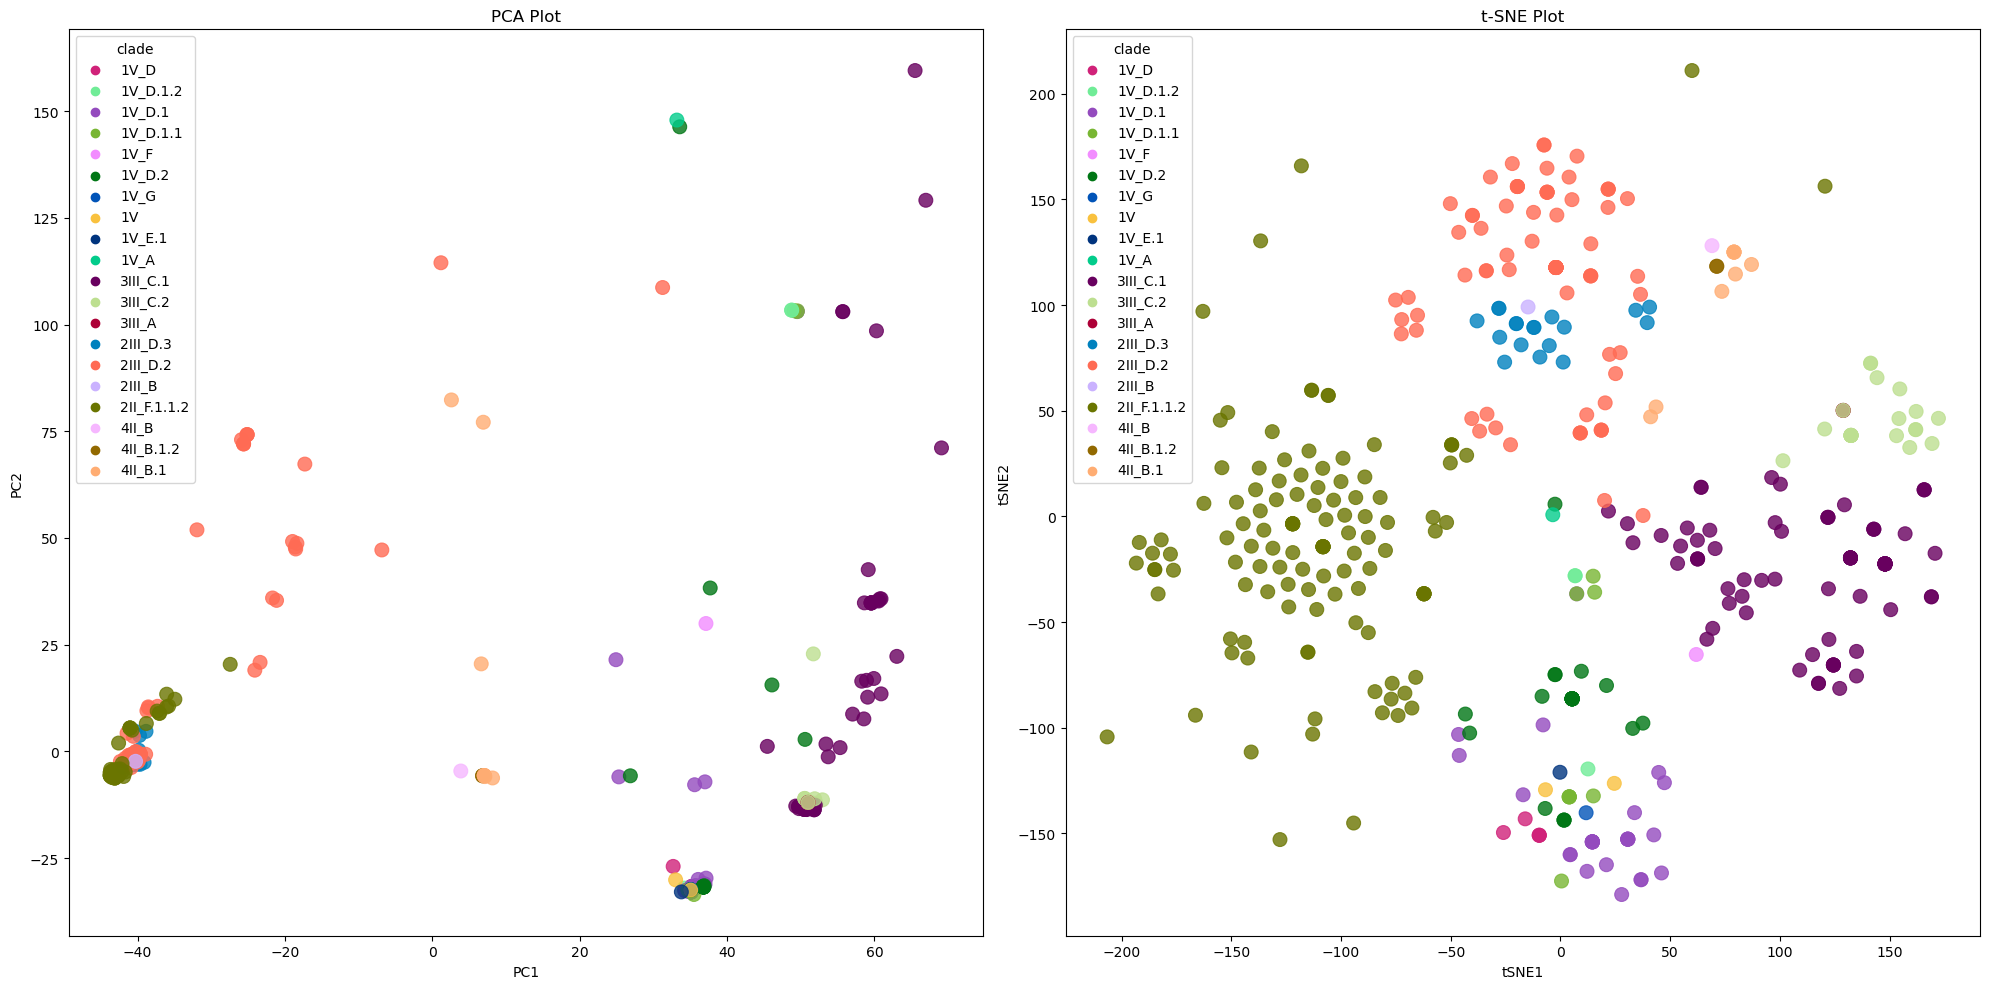

In [168]:
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord
from Bio import AlignIO, SeqIO

# Load the alignment
align = AlignIO.read('/Users/ricardorivero/Documents/DENV/dimensionality_reduction/colombian_seqs_pca.aligned.fasta', "fasta")

# Subset the alignment from position 934 to 2418 (adjusted for 0-indexing)
start_pos = 934  # 935 in 1-indexed
end_pos = 2418   # No need to adjust, as slicing is exclusive for the end position
subset_align = align[:, start_pos:end_pos]

# Translate the nucleotide sequences to protein sequences
protein_records = []
for record in subset_align:
    dna_seq = str(record.seq)
    protein_seq = Seq(dna_seq).translate(to_stop=False)  # Translate without stopping at the first stop codon
    protein_record = SeqRecord(protein_seq, id=record.id.split('|')[0], description="")  # Extract proper sequence name
    protein_records.append(protein_record)

# Optionally, save the translated protein alignment to a new file
with open('/Users/ricardorivero/Documents/DENV/dimensionality_reduction/subsetted_E_alignment_protein.fasta', 'w') as output_handle:
    SeqIO.write(protein_records, output_handle, "fasta")

# Reload the translated protein alignment
eprot_align = AlignIO.read('/Users/ricardorivero/Documents/DENV/dimensionality_reduction/subsetted_E_alignment_protein.fasta', "fasta")

# Create a dictionary where keys are sequence names and values are lists of translated protein sequences
# Keys (sequence names) should be record.id, and values are the list of amino acids in each sequence
data = {record.id: list(str(record.seq)) for record in eprot_align}  # record.id is the proper sequence name

# Convert the dictionary to a pandas DataFrame
e_aln_df = pd.DataFrame.from_dict(data, orient='index')

# Reset the index so the sequence names are the first column
e_aln_df.reset_index(inplace=True)

# Rename the first column to 'sequence_name'
e_aln_df.rename(columns={'index': 'sequence_name'}, inplace=True)

# Optionally, rename the protein position columns to be 1-based
e_aln_df.columns = ['sequence_name'] + [f'pos_{i+1}' for i in range(e_aln_df.shape[1] - 1)]

# Print the first few rows to verify that the sequence names are correct
print(e_aln_df['sequence_name'].head())

# Load the subsetted alignment and encode it
# Define an amino acid to numeric encoding
amino_acid_encoding = {
    'A': 0,  # Alanine
    'C': 1,  # Cysteine
    'D': 2,  # Aspartic acid
    'E': 3,  # Glutamic acid
    'F': 4,  # Phenylalanine
    'G': 5,  # Glycine
    'H': 6,  # Histidine
    'I': 7,  # Isoleucine
    'K': 8,  # Lysine
    'L': 9,  # Leucine
    'M': 10, # Methionine
    'N': 11, # Asparagine
    'P': 12, # Proline
    'Q': 13, # Glutamine
    'R': 14, # Arginine
    'S': 15, # Serine
    'T': 16, # Threonine
    'V': 17, # Valine
    'W': 18, # Tryptophan
    'Y': 19, # Tyrosine
    'X': -1  # Unknown or missing positions
}

# Ensure proper encoding of non-standard amino acids and replace them with X
e_aln_df.iloc[:, 1:] = e_aln_df.iloc[:, 1:].replace(to_replace=r'[^ACDEFGHIKLMNPQRSTVWYX]', value='X', regex=True)

# Replace amino acids with numerical encoding
e_aln_encoded = e_aln_df.iloc[:, 1:].replace(amino_acid_encoding)

# Rest of the PCA and t-SNE workflow
X = e_aln_encoded.values
np.random.seed(1007) #Today's date
X = pd.DataFrame(X).dropna().values  # Drop NaNs

# Perform PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Perform t-SNE
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X)

# Create PCA and t-SNE DataFrames
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
tsne_df = pd.DataFrame(X_tsne, columns=['tSNE1', 'tSNE2'])

# Load lineage data from metadata
df_metadata = gisaid_metadata[['Virus name', 'clade']]  # Ensure this contains the correct lineage data
df_metadata.rename(columns={'Virus name': 'sequence_name'}, inplace=True)  # Rename the column to match sequence names
print(df_metadata['sequence_name'].head())

# Ensure 'sequence_name' is a proper column (not the index)
e_aln_df.reset_index(drop=True, inplace=True)  # Drop the old index if necessary
df_metadata.reset_index(drop=True, inplace=True)  # Ensure metadata also has no index issues

# Make sure 'sequence_name' exists in both DataFrames
print(e_aln_df['sequence_name'].head())
print(df_metadata['sequence_name'].head())

# Merge lineage info into PCA and t-SNE DataFrames
pca_df['sequence_name'] = e_aln_df['sequence_name']  # Add sequence names to PCA DataFrame
tsne_df['sequence_name'] = e_aln_df['sequence_name']  # Add sequence names to t-SNE DataFrame

# Perform the merge
pca_df = pca_df.merge(df_metadata, on='sequence_name', how='left')
tsne_df = tsne_df.merge(df_metadata, on='sequence_name', how='left')

# Check if the merge worked correctly
print(pca_df[['sequence_name', 'clade']].head())
print(tsne_df[['sequence_name', 'clade']].head())

print(tsne_df['clade'])

colors = ["#d02279",
"#70ec97",
"#944bbe",
"#78b633",
"#f28cff",
"#007615",
"#0154b8",
"#f9c13e",
"#00347e",
"#02cc8b",
"#68005f",
"#bddf90",
"#ad0037",
"#0081be",
"#ff6b54",
"#cab2ff",
"#6a7500",
"#f6b7ff",
"#926900",
"#ffad73"]

# Plotting PCA with lineage color and custom colors
plt.figure(figsize=(20, 10))

# PCA Plot
plt.subplot(1, 2, 1)
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='clade', palette=colors, s=100, legend='full', alpha=0.8,edgecolor=None)
plt.title('PCA Plot')
plt.xlabel('PC1')
plt.ylabel('PC2')

# t-SNE Plot
plt.subplot(1, 2, 2)
sns.scatterplot(data=tsne_df, x='tSNE1', y='tSNE2', hue='clade', palette=colors, s=100, legend='full', alpha=0.8, edgecolor=None)
plt.title('t-SNE Plot')
plt.xlabel('tSNE1')
plt.ylabel('tSNE2')

plt.tight_layout()
plt.savefig('/Users/ricardorivero/Documents/DENV/dimensionality_reduction/colombian_seqs_pca_tsne_prot.jpeg', dpi=1200)
plt.show()

Alignment with 421 rows and 1484 columns
ATGGCCATGCGATGCGTGGGAATAGGCAACAGAGACTTCGTTGA...GGT hDenV1/Colombia/RIS-INS-476947/2016|EPI_ISL_17783293|2016-04-26
NNNNNNNNNNNNNNNNNNNNNNNAGGCAACAGAGACTTCGTTGA...GGT hDenV1/Colombia/un-INS-484940/2016|EPI_ISL_17783296|2016-07-07
ATGGCCATGCGATGCGTGGGAATAGGCAACAGAGACTTCGTTGA...GGT hDenV1/Colombia/un-INS-484948/2016|EPI_ISL_17783299|2016-07-12
ATGGCCATGCGATGCGTGGGAATAGGCAATAGAGACTTTGTTGA...GGT hDenV1/Colombia/un-INS-424233/2013|EPI_ISL_17783301|2013-06-01
ATGGCCATGCGATGCGTGGGAATAGGCAACAGAGACTTCGTTGA...GGT hDenV1/Colombia/un-INS-484942/2016|EPI_ISL_17783298|2016-07-14
ATGGCCATGCGATGCGTGGGAATAGGCAACAGAGACTTCGTTGA...GGT hDenV1/Colombia/CAU-INS-483718/2016|EPI_ISL_17783295|2016-06-24
ATGGCCATGCGATGCGTGGGAATAGGCAACAGAGACTTCGTTGA...GGT hDenV1/Colombia/ANT-INS-485061/2016|EPI_ISL_17783300|2016-08-27
ATGGCCATGCGATGCGTGGGAATAGGCAACAGAGACTTCGTTGA...GGT hDenV1/Colombia/FUADLA-AFI059_677/2021|EPI_ISL_9769066|2021-01-25
ATGGCCATGCGATGCGTGGGAATAGGCAACAGAGACTTCGT

/var/folders/8v/6y3r5h_x0dv5t5875drggrtc0000gn/T/ipykernel_77814/3214599212.py:78: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_metadata.rename(columns={'Virus name': 'sequence_name'}, inplace=True)  # Rename the column to match sequence names


0
0


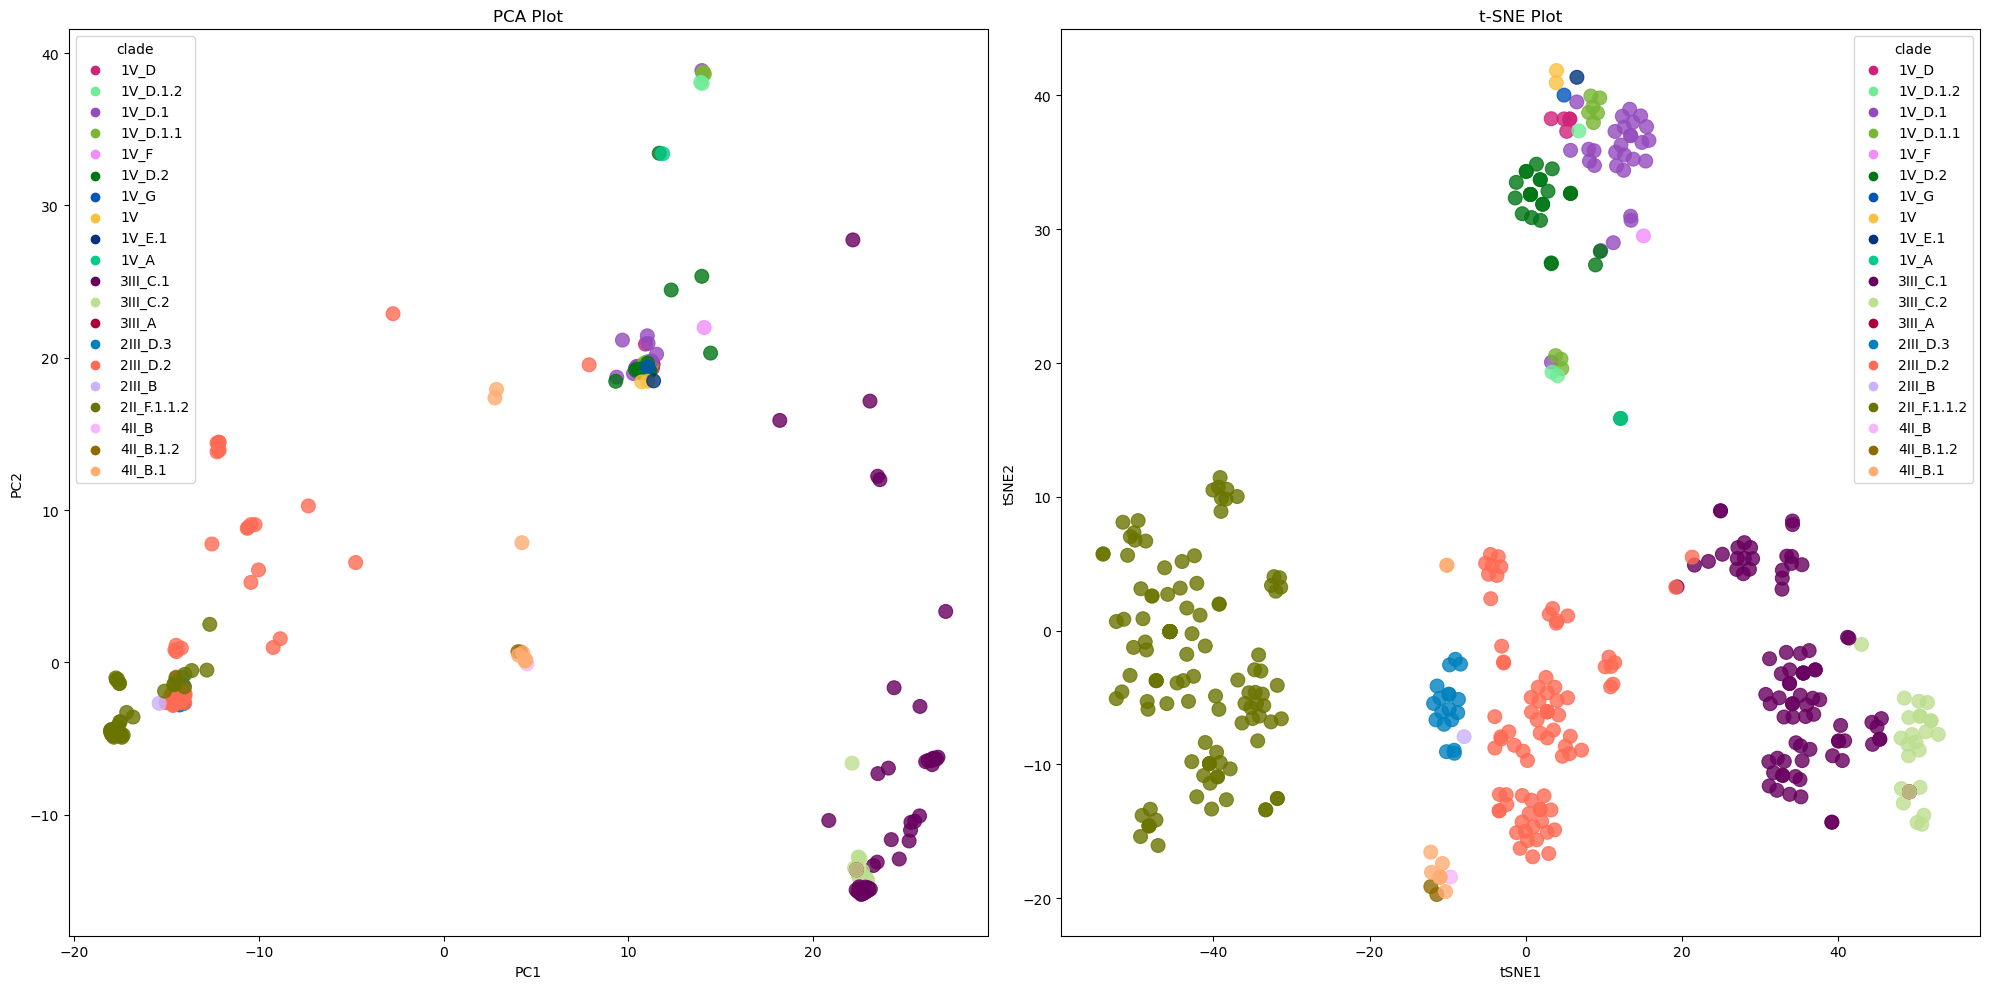

In [169]:
#Re-do with protein
from Bio import AlignIO

# Load the alignment
align = AlignIO.read('/Users/ricardorivero/Documents/DENV/dimensionality_reduction/colombian_seqs_pca.aligned.fasta', "fasta")

# Subset the alignment from position 934 to 2418 (adjusted for 0-indexing)
start_pos = 934  # 935 in 1-indexed, so subtract 1 for 0-indexing
end_pos = 2418   # No need to adjust, as slicing is exclusive for the end position

# Slice the alignment
subset_align = align[:, start_pos:end_pos]

# Optionally, save the subsetted alignment to a new file
with open('/Users/ricardorivero/Documents/DENV/dimensionality_reduction/subsetted_E_alignment.fasta', 'w') as output_handle:
    AlignIO.write(subset_align, output_handle, "fasta")

# Print to verify the subsetted alignment
print(subset_align)


# Load the alignment
e_align = AlignIO.read('/Users/ricardorivero/Documents/DENV/dimensionality_reduction/subsetted_E_alignment.fasta', "fasta")

# Create a dictionary where keys are sequence names (the first part of the header) and values are the sequences
data = {record.id.split()[0]: list(str(record.seq)) for record in e_align}

# Convert the dictionary to a pandas DataFrame
e_aln_df = pd.DataFrame.from_dict(data, orient='index')

# Reset the index so the sequence names are the first column
e_aln_df.reset_index(inplace=True)

# Rename the first column to 'sequence_name'
e_aln_df.rename(columns={'index': 'sequence_name'}, inplace=True)



# Optionally, rename the nucleotide position columns to be 1-based
e_aln_df.columns = ['sequence_name'] + [f'pos_{i+1}' for i in range(e_aln_df.shape[1] - 1)]

# Print the DataFrame to verify
print(e_aln_df['sequence_name'][1])

# Optionally, save to a CSV file
e_aln_df.to_csv('/Users/ricardorivero/Documents/DENV/dimensionality_reduction/subsetted_alignment.csv', index=False)

#Let's now do the t-SNE
# Load the subsetted alignment and encode it
e_aln_df = pd.read_csv('/Users/ricardorivero/Documents/DENV/dimensionality_reduction/subsetted_alignment.csv')
e_aln_df.iloc[:, 1:] = e_aln_df.iloc[:, 1:].replace(to_replace=r'[^ACGTN]', value='N', regex=True)
nucleotide_encoding = {'A': 0, 'C': 1, 'G': 2, 'T': 3, 'N': -1}
e_aln_encoded = e_aln_df.iloc[:, 1:].replace(nucleotide_encoding)
X = e_aln_encoded.values

np.random.seed(1007) #Today's date
X = pd.DataFrame(X).dropna().values  # Drop NaNs

# Perform PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Perform t-SNE
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X)

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
tsne_df = pd.DataFrame(X_tsne, columns=['tSNE1', 'tSNE2'])

#Now let's color the points based on the lineage assignation
import seaborn as sns

# Assuming your original DataFrame with sequence names and lineage is called `df_metadata`
# The DataFrame should have columns like 'sequence_name' and 'lineage'

# Merge PCA and t-SNE results with lineage information
df_metadata = gisaid_metadata[['Virus name', 'clade']]  # Ensure this contains the correct lineage data
df_metadata.rename(columns={'Virus name': 'sequence_name'}, inplace=True)  # Rename the column to match sequence names


e_aln_df['sequence_name'] = e_aln_df['sequence_name'].str.split('|').str[0]
# Merge lineage info with PCA and t-SNE results based on sequence name
pca_df['sequence_name'] = e_aln_df['sequence_name']  # Add sequence names to PCA DataFrame
tsne_df['sequence_name'] = e_aln_df['sequence_name']  # Add sequence names to t-SNE DataFrame

# Merge lineage into PCA and t-SNE DataFrames
pca_df = pca_df.merge(df_metadata, on='sequence_name', how='left')
tsne_df = tsne_df.merge(df_metadata, on='sequence_name', how='left')

print(pca_df['clade'].isna().sum())
print(tsne_df['clade'].isna().sum())

colors = ["#d02279",
"#70ec97",
"#944bbe",
"#78b633",
"#f28cff",
"#007615",
"#0154b8",
"#f9c13e",
"#00347e",
"#02cc8b",
"#68005f",
"#bddf90",
"#ad0037",
"#0081be",
"#ff6b54",
"#cab2ff",
"#6a7500",
"#f6b7ff",
"#926900",
"#ffad73"]

# Plotting PCA with lineage color and custom colors
plt.figure(figsize=(20, 10))

# PCA Plot
plt.subplot(1, 2, 1)
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='clade', palette=colors, s=100, legend='full',alpha=0.8,edgecolor=None)
plt.title('PCA Plot')
plt.xlabel('PC1')
plt.ylabel('PC2')

# t-SNE Plot
plt.subplot(1, 2, 2)
sns.scatterplot(data=tsne_df, x='tSNE1', y='tSNE2', hue='clade', palette=colors, s=100, legend='full',alpha=0.8,edgecolor=None)
plt.title('t-SNE Plot')
plt.xlabel('tSNE1')
plt.ylabel('tSNE2')
plt.tight_layout()
plt.savefig('/Users/ricardorivero/Documents/DENV/dimensionality_reduction/colombian_seqs_pca_tsne_nuc.jpeg', dpi=1200)
plt.show()